# Feature Engineering dalam Text Mining
### Implementasi: Bag of Words · TF-IDF · N-Gram

Notebook ini membangun pemahaman dari bawah ke atas:
1. **Manual dari scratch** — agar paham mekanismenya
2. **Dengan scikit-learn** — agar siap dipakai di project nyata
3. **Visualisasi** — agar bisa diinterpretasikan dengan jelas

---
## Setup: Install & Import Library

In [ ]:
# Install jika belum ada
# !pip install scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import math
from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print("✅ Semua library berhasil diimport.")

✅ Semua library berhasil diimport.


---
## Corpus Data

Kita gunakan corpus kecil bertema ekonomi agar mudah diverifikasi secara manual.

In [ ]:
corpus = [
    "bank sentral naikkan suku bunga untuk kendalikan inflasi",
    "inflasi meningkat akibat kenaikan harga bahan pokok",
    "bank sentral pantau stabilitas nilai tukar dan inflasi",
    "harga bahan pokok naik menjelang hari raya",
    "suku bunga acuan bank dipertahankan stabil bulan ini"
]

print("📄 Corpus yang digunakan:")
print("-" * 60)
for i, doc in enumerate(corpus):
    print(f"D{i+1}: {doc}")

📄 Corpus yang digunakan:
------------------------------------------------------------
D1: bank sentral naikkan suku bunga untuk kendalikan inflasi
D2: inflasi meningkat akibat kenaikan harga bahan pokok
D3: bank sentral pantau stabilitas nilai tukar dan inflasi
D4: harga bahan pokok naik menjelang hari raya
D5: suku bunga acuan bank dipertahankan stabil bulan ini


---
# BAGIAN 1 — BAG OF WORDS (BoW)

## 1A. Implementasi Manual (dari Scratch)

In [ ]:
# ── LANGKAH 1: Bangun Vocabulary ──────────────────────────────────────────
# Tokenisasi sederhana: split by spasi
tokenized = [doc.split() for doc in corpus]

# Kumpulkan semua kata unik, lalu urutkan agar konsisten
all_words = [word for tokens in tokenized for word in tokens]
vocabulary = sorted(set(all_words))

print(f"📚 Ukuran Vocabulary: {len(vocabulary)} kata unik")
print(f"\nVocabulary:")
print(vocabulary)

📚 Ukuran Vocabulary: 28 kata unik

Vocabulary:
['acuan', 'akibat', 'bahan', 'bank', 'bulan', 'bunga', 'dan', 'dipertahankan', 'harga', 'hari', 'inflasi', 'ini', 'kenaikan', 'kendalikan', 'meningkat', 'menjelang', 'naik', 'naikkan', 'nilai', 'pantau', 'pokok', 'raya', 'sentral', 'stabil', 'stabilitas', 'suku', 'tukar', 'untuk']


In [ ]:
# ── LANGKAH 2: Buat Document-Term Matrix (DTM) secara manual ──────────────

def build_bow_manual(tokenized_docs, vocab):
    """
    Membangun Document-Term Matrix dari daftar token.
    Setiap baris = satu dokumen
    Setiap kolom = satu kata dalam vocabulary
    Nilai       = jumlah kemunculan kata di dokumen tersebut (raw count)
    """
    word_to_idx = {word: idx for idx, word in enumerate(vocab)}
    dtm = np.zeros((len(tokenized_docs), len(vocab)), dtype=int)

    for doc_idx, tokens in enumerate(tokenized_docs):
        for token in tokens:
            if token in word_to_idx:
                col_idx = word_to_idx[token]
                dtm[doc_idx, col_idx] += 1

    return dtm


bow_matrix = build_bow_manual(tokenized, vocabulary)

# Tampilkan sebagai DataFrame agar mudah dibaca
bow_df = pd.DataFrame(bow_matrix, columns=vocabulary,
                       index=[f"D{i+1}" for i in range(len(corpus))])

print("📊 Document-Term Matrix — Bag of Words (raw count):")
print("-" * 80)
print(bow_df.to_string())

📊 Document-Term Matrix — Bag of Words (raw count):
--------------------------------------------------------------------------------
    acuan  akibat  bahan  bank  bulan  bunga  dan  dipertahankan  harga  hari  inflasi  ini  kenaikan  kendalikan  meningkat  menjelang  naik  naikkan  nilai  pantau  pokok  raya  sentral  stabil  stabilitas  suku  tukar  untuk
D1      0       0      0     1      0      1    0              0      0     0        1    0         0           1          0          0     0        1      0       0      0     0        1       0           0     1      0      1
D2      0       1      1     0      0      0    0              0      1     0        1    0         1           0          1          0     0        0      0       0      1     0        0       0           0     0      0      0
D3      0       0      0     1      0      0    1              0      0     0        1    0         0           0          0          0     0        0      1       1      0     0      

In [ ]:
# ── LANGKAH 3: Analisis Sparsity ──────────────────────────────────────────

total_cells   = bow_matrix.size
nonzero_cells = np.count_nonzero(bow_matrix)
zero_cells    = total_cells - nonzero_cells
sparsity      = zero_cells / total_cells * 100

print("🔍 Analisis Sparsity:")
print(f"   Total sel dalam matriks : {total_cells}")
print(f"   Sel bernilai non-zero   : {nonzero_cells}")
print(f"   Sel bernilai nol        : {zero_cells}")
print(f"   Tingkat sparsity        : {sparsity:.1f}%")
print()
print(f"   → Hanya {100 - sparsity:.1f}% dari matriks yang terisi.")
print(f"     Bayangkan ini di corpus 10.000 dokumen — mayoritas sel akan nol.")

🔍 Analisis Sparsity:
   Total sel dalam matriks : 140
   Sel bernilai non-zero   : 38
   Sel bernilai nol        : 102
   Tingkat sparsity        : 72.9%

   → Hanya 27.1% dari matriks yang terisi.
     Bayangkan ini di corpus 10.000 dokumen — mayoritas sel akan nol.


## 1B. Implementasi dengan scikit-learn

In [ ]:
# CountVectorizer = BoW versi scikit-learn
# Parameter penting:
#   min_df   : abaikan kata yang muncul di < N dokumen (filter noise)
#   max_df   : abaikan kata yang muncul di > X% dokumen (filter stopword otomatis)
#   max_features : batasi vocabulary ke N kata teratas berdasarkan frekuensi

cv = CountVectorizer()
bow_sklearn = cv.fit_transform(corpus)  # returns sparse matrix

vocab_sklearn = cv.get_feature_names_out()
bow_sklearn_df = pd.DataFrame(
    bow_sklearn.toarray(),
    columns=vocab_sklearn,
    index=[f"D{i+1}" for i in range(len(corpus))]
)

print("📊 BoW dengan scikit-learn CountVectorizer:")
print(bow_sklearn_df.to_string())

📊 BoW dengan scikit-learn CountVectorizer:
    acuan  akibat  bahan  bank  bulan  bunga  dan  dipertahankan  harga  hari  inflasi  ini  kenaikan  kendalikan  meningkat  menjelang  naik  naikkan  nilai  pantau  pokok  raya  sentral  stabil  stabilitas  suku  tukar  untuk
D1      0       0      0     1      0      1    0              0      0     0        1    0         0           1          0          0     0        1      0       0      0     0        1       0           0     1      0      1
D2      0       1      1     0      0      0    0              0      1     0        1    0         1           0          1          0     0        0      0       0      1     0        0       0           0     0      0      0
D3      0       0      0     1      0      0    1              0      0     0        1    0         0           0          0          0     0        0      1       1      0     0        1       0           1     0      1      0
D4      0       0      1     0      0      0 

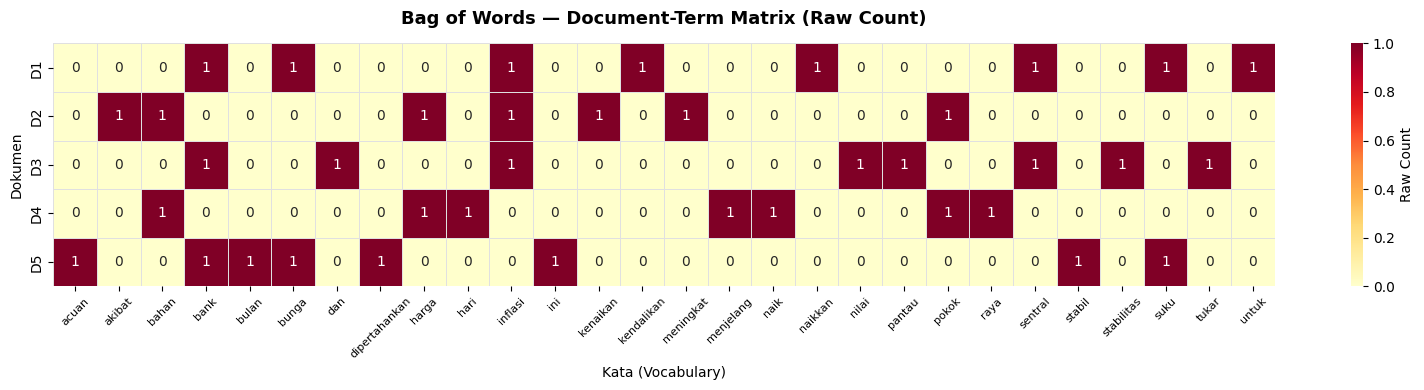


💡 Sel putih = nilai 0 (kata tidak ada di dokumen tersebut)
   Semakin gelap warnanya, semakin sering kata itu muncul.


In [ ]:
# ── Visualisasi BoW sebagai Heatmap ───────────────────────────────────────

fig, ax = plt.subplots(figsize=(16, 4))

sns.heatmap(
    bow_sklearn_df,
    annot=True, fmt='d',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='#e0e0e0',
    ax=ax,
    cbar_kws={'label': 'Raw Count'}
)

ax.set_title('Bag of Words — Document-Term Matrix (Raw Count)',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Kata (Vocabulary)', fontsize=10)
ax.set_ylabel('Dokumen', fontsize=10)
ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.show()

print("\n💡 Sel putih = nilai 0 (kata tidak ada di dokumen tersebut)")
print("   Semakin gelap warnanya, semakin sering kata itu muncul.")

---
# BAGIAN 2 — TF-IDF

## 2A. Implementasi Manual Step-by-Step

In [ ]:
# ── LANGKAH 1: Hitung TF per kata per dokumen ─────────────────────────────
# TF(t, d) = jumlah kemunculan kata t di dokumen d / total kata di dokumen d

def compute_tf(tokenized_doc):
    """
    Menghitung Term Frequency untuk satu dokumen.
    Return: dict {kata: TF_score}
    """
    total_words = len(tokenized_doc)
    count = Counter(tokenized_doc)
    return {word: count[word] / total_words for word in count}


tf_per_doc = [compute_tf(tokens) for tokens in tokenized]

# Tampilkan TF untuk D1 dan D2 sebagai contoh
for i in [0, 1]:
    print(f"\n📄 TF untuk D{i+1}: \"{corpus[i]}\"")
    print(f"   Total kata: {len(tokenized[i])}")
    for word, tf in sorted(tf_per_doc[i].items()):
        count = Counter(tokenized[i])[word]
        print(f"   '{word}': {count}/{len(tokenized[i])} = {tf:.4f}")


📄 TF untuk D1: "bank sentral naikkan suku bunga untuk kendalikan inflasi"
   Total kata: 8
   'bank': 1/8 = 0.1250
   'bunga': 1/8 = 0.1250
   'inflasi': 1/8 = 0.1250
   'kendalikan': 1/8 = 0.1250
   'naikkan': 1/8 = 0.1250
   'sentral': 1/8 = 0.1250
   'suku': 1/8 = 0.1250
   'untuk': 1/8 = 0.1250

📄 TF untuk D2: "inflasi meningkat akibat kenaikan harga bahan pokok"
   Total kata: 7
   'akibat': 1/7 = 0.1429
   'bahan': 1/7 = 0.1429
   'harga': 1/7 = 0.1429
   'inflasi': 1/7 = 0.1429
   'kenaikan': 1/7 = 0.1429
   'meningkat': 1/7 = 0.1429
   'pokok': 1/7 = 0.1429


In [ ]:
# ── LANGKAH 2: Hitung IDF per kata di seluruh corpus ─────────────────────
# IDF(t) = log( N / df(t) )
# N    = total dokumen
# df(t) = jumlah dokumen yang mengandung kata t

def compute_idf(tokenized_docs, vocab):
    """
    Menghitung Inverse Document Frequency untuk setiap kata dalam vocabulary.
    Return: dict {kata: IDF_score}
    """
    N = len(tokenized_docs)
    idf_scores = {}

    for word in vocab:
        # Hitung di berapa dokumen kata ini muncul
        df = sum(1 for tokens in tokenized_docs if word in tokens)

        # IDF murni: log(N/df)
        # Jika df=0 (tidak ada dokumen mengandung kata ini), skip
        if df > 0:
            idf_scores[word] = math.log(N / df)
        else:
            idf_scores[word] = 0.0

    return idf_scores


idf_scores = compute_idf(tokenized, vocabulary)

# Tampilkan IDF semua kata, diurutkan dari tertinggi ke terendah
idf_sorted = sorted(idf_scores.items(), key=lambda x: x[1], reverse=True)

print(f"📊 IDF Scores (N = {len(corpus)} dokumen):")
print("-" * 50)
print(f"{'Kata':<20} {'df':>5}   {'IDF':>8}   Interpretasi")
print("-" * 50)
for word, idf_val in idf_sorted:
    df_count = sum(1 for tokens in tokenized if word in tokens)
    if idf_val == 0:
        note = "⚠️  muncul di SEMUA dok → tidak informatif"
    elif df_count == 1:
        note = "✅ unik → sangat informatif"
    else:
        note = f"🔵 muncul di {df_count} dok"
    print(f"  {word:<18} {df_count:>5}   {idf_val:>8.4f}   {note}")

📊 IDF Scores (N = 5 dokumen):
--------------------------------------------------
Kata                    df        IDF   Interpretasi
--------------------------------------------------
  acuan                  1     1.6094   ✅ unik → sangat informatif
  akibat                 1     1.6094   ✅ unik → sangat informatif
  bulan                  1     1.6094   ✅ unik → sangat informatif
  dan                    1     1.6094   ✅ unik → sangat informatif
  dipertahankan          1     1.6094   ✅ unik → sangat informatif
  hari                   1     1.6094   ✅ unik → sangat informatif
  ini                    1     1.6094   ✅ unik → sangat informatif
  kenaikan               1     1.6094   ✅ unik → sangat informatif
  kendalikan             1     1.6094   ✅ unik → sangat informatif
  meningkat              1     1.6094   ✅ unik → sangat informatif
  menjelang              1     1.6094   ✅ unik → sangat informatif
  naik                   1     1.6094   ✅ unik → sangat informatif
  naikkan  

In [ ]:
# ── LANGKAH 3: Hitung TF-IDF = TF × IDF ─────────────────────────────────

def compute_tfidf_matrix(tf_per_doc, idf_scores, vocab, n_docs):
    """
    Membangun TF-IDF Matrix lengkap.
    Setiap baris = satu dokumen
    Setiap kolom = satu kata
    Nilai        = TF(t,d) × IDF(t)
    """
    matrix = np.zeros((n_docs, len(vocab)))

    for doc_idx, tf_dict in enumerate(tf_per_doc):
        for word_idx, word in enumerate(vocab):
            tf  = tf_dict.get(word, 0.0)
            idf = idf_scores.get(word, 0.0)
            matrix[doc_idx, word_idx] = tf * idf

    return matrix


tfidf_manual = compute_tfidf_matrix(tf_per_doc, idf_scores, vocabulary, len(corpus))

tfidf_manual_df = pd.DataFrame(
    tfidf_manual,
    columns=vocabulary,
    index=[f"D{i+1}" for i in range(len(corpus))]
)

print("📊 TF-IDF Matrix (implementasi manual):")
print("-" * 80)
print(tfidf_manual_df.round(4).to_string())

print("\n💡 Perhatikan: kata 'inflasi' (ada di 3 dokumen) mendapat IDF = 0")
print("   → TF-IDF-nya pun 0 di semua dokumen, meskipun sering muncul.")

📊 TF-IDF Matrix (implementasi manual):
--------------------------------------------------------------------------------
     acuan  akibat   bahan    bank   bulan   bunga     dan  dipertahankan   harga    hari  inflasi     ini  kenaikan  kendalikan  meningkat  menjelang    naik  naikkan   nilai  pantau   pokok    raya  sentral  stabil  stabilitas    suku   tukar   untuk
D1  0.0000  0.0000  0.0000  0.0639  0.0000  0.1145  0.0000         0.0000  0.0000  0.0000   0.0639  0.0000    0.0000      0.2012     0.0000     0.0000  0.0000   0.2012  0.0000  0.0000  0.0000  0.0000   0.1145  0.0000      0.0000  0.1145  0.0000  0.2012
D2  0.0000  0.2299  0.1309  0.0000  0.0000  0.0000  0.0000         0.0000  0.1309  0.0000   0.0730  0.0000    0.2299      0.0000     0.2299     0.0000  0.0000   0.0000  0.0000  0.0000  0.1309  0.0000   0.0000  0.0000      0.0000  0.0000  0.0000  0.0000
D3  0.0000  0.0000  0.0000  0.0639  0.0000  0.0000  0.2012         0.0000  0.0000  0.0000   0.0639  0.0000    0.0000     

In [ ]:
# ── Tampilkan top-3 kata paling informatif per dokumen ────────────────────

print("🏆 Top-3 Kata Paling Informatif per Dokumen (berdasarkan TF-IDF):")
print("=" * 70)
for i, doc in enumerate(corpus):
    row = tfidf_manual_df.iloc[i]
    top3 = row[row > 0].nlargest(3)
    print(f"\nD{i+1}: \"{doc}\"")
    for word, score in top3.items():
        print(f"   → '{word}': {score:.4f}")

🏆 Top-3 Kata Paling Informatif per Dokumen (berdasarkan TF-IDF):

D1: "bank sentral naikkan suku bunga untuk kendalikan inflasi"
   → 'kendalikan': 0.2012
   → 'naikkan': 0.2012
   → 'untuk': 0.2012

D2: "inflasi meningkat akibat kenaikan harga bahan pokok"
   → 'akibat': 0.2299
   → 'kenaikan': 0.2299
   → 'meningkat': 0.2299

D3: "bank sentral pantau stabilitas nilai tukar dan inflasi"
   → 'dan': 0.2012
   → 'nilai': 0.2012
   → 'pantau': 0.2012

D4: "harga bahan pokok naik menjelang hari raya"
   → 'hari': 0.2299
   → 'menjelang': 0.2299
   → 'naik': 0.2299

D5: "suku bunga acuan bank dipertahankan stabil bulan ini"
   → 'acuan': 0.2012
   → 'bulan': 0.2012
   → 'dipertahankan': 0.2012


## 2B. Implementasi dengan scikit-learn

In [ ]:
# TfidfVectorizer menggunakan formula yang sedikit dimodifikasi dari manual:
# IDF = log((N+1)/(df+1)) + 1   → disebut 'smooth IDF'
# Ini mencegah pembagian nol dan IDF bernilai negatif
# Hasilnya juga dinormalisasi dengan L2 norm (panjang vektor = 1)

tfidf_vec = TfidfVectorizer()
tfidf_sklearn = tfidf_vec.fit_transform(corpus)

tfidf_sklearn_df = pd.DataFrame(
    tfidf_sklearn.toarray(),
    columns=tfidf_vec.get_feature_names_out(),
    index=[f"D{i+1}" for i in range(len(corpus))]
)

print("📊 TF-IDF dengan scikit-learn (smooth IDF + L2 normalization):")
print(tfidf_sklearn_df.round(4).to_string())

print("\n📌 Catatan perbedaan vs manual:")
print("   • Scikit-learn pakai smooth IDF: log((N+1)/(df+1))+1 → nilai tidak pernah 0")
print("   • Setiap baris dinormalisasi L2 sehingga panjang vektor = 1")
print("   • Cocok untuk machine learning (SVM, cosine similarity, dll)")

📊 TF-IDF dengan scikit-learn (smooth IDF + L2 normalization):
     acuan  akibat   bahan    bank   bulan   bunga     dan  dipertahankan   harga    hari  inflasi     ini  kenaikan  kendalikan  meningkat  menjelang    naik  naikkan   nilai  pantau   pokok    raya  sentral  stabil  stabilitas    suku   tukar   untuk
D1  0.0000  0.0000  0.0000  0.2769  0.0000  0.3336  0.0000         0.0000  0.0000  0.0000   0.2769  0.0000    0.0000      0.4135     0.0000     0.0000  0.0000   0.4135  0.0000  0.0000  0.0000  0.0000   0.3336  0.0000      0.0000  0.3336  0.0000  0.4135
D2  0.0000  0.4303  0.3471  0.0000  0.0000  0.0000  0.0000         0.0000  0.3471  0.0000   0.2882  0.0000    0.4303      0.0000     0.4303     0.0000  0.0000   0.0000  0.0000  0.0000  0.3471  0.0000   0.0000  0.0000      0.0000  0.0000  0.0000  0.0000
D3  0.0000  0.0000  0.0000  0.2617  0.0000  0.0000  0.3908         0.0000  0.0000  0.0000   0.2617  0.0000    0.0000      0.0000     0.0000     0.0000  0.0000   0.0000  0.3908  0.

📊 Perbandingan BoW vs TF-IDF untuk D2:
   Dokumen: "inflasi meningkat akibat kenaikan harga bahan pokok"

           BoW (raw count)  TF-IDF (sklearn)
akibat                   1            0.4303
meningkat                1            0.4303
kenaikan                 1            0.4303
harga                    1            0.3471
bahan                    1            0.3471
pokok                    1            0.3471
inflasi                  1            0.2882


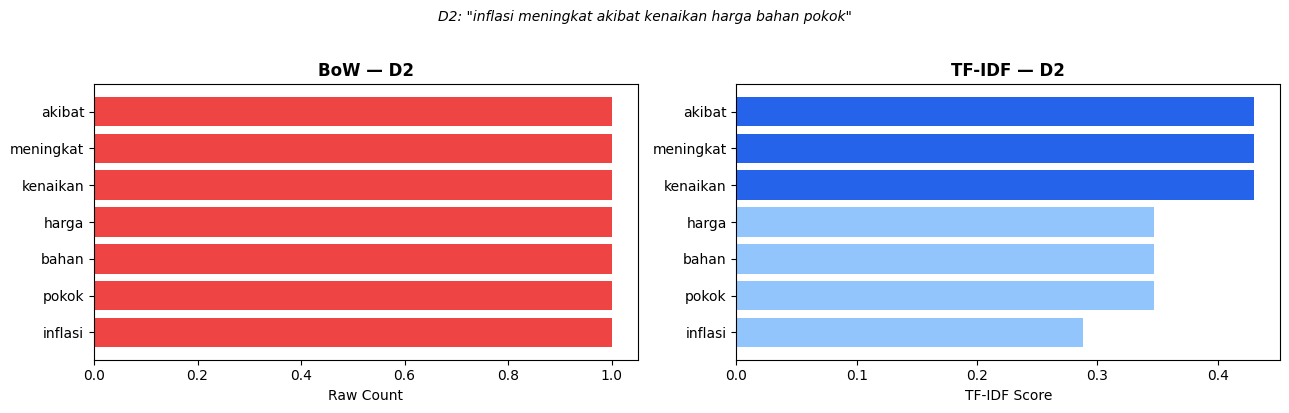


💡 Di BoW semua kata terhitung sama (raw count).
   Di TF-IDF, kata yang lebih spesifik ke dokumen ini mendapat skor lebih tinggi.


In [ ]:
# ── Perbandingan BoW vs TF-IDF untuk satu dokumen ────────────────────────

doc_idx  = 1   # D2: "inflasi meningkat akibat kenaikan harga bahan pokok"

bow_row   = bow_sklearn_df.iloc[doc_idx]
tfidf_row = tfidf_sklearn_df.iloc[doc_idx]

# Ambil hanya kata yang hadir di dokumen ini
present_words = bow_row[bow_row > 0].index.tolist()

compare_df = pd.DataFrame({
    'BoW (raw count)': bow_row[present_words].values,
    'TF-IDF (sklearn)': tfidf_row[present_words].values
}, index=present_words).sort_values('TF-IDF (sklearn)', ascending=False)

print(f"📊 Perbandingan BoW vs TF-IDF untuk D{doc_idx+1}:")
print(f"   Dokumen: \"{corpus[doc_idx]}\"")
print()
print(compare_df.round(4).to_string())

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors_bow   = ['#ef4444' if v == max(compare_df['BoW (raw count)']) else '#fca5a5'
                for v in compare_df['BoW (raw count)']]
colors_tfidf = ['#2563eb' if v == max(compare_df['TF-IDF (sklearn)']) else '#93c5fd'
                for v in compare_df['TF-IDF (sklearn)']]

axes[0].barh(compare_df.index, compare_df['BoW (raw count)'], color=colors_bow)
axes[0].set_title(f'BoW — D{doc_idx+1}', fontweight='bold')
axes[0].set_xlabel('Raw Count')
axes[0].invert_yaxis()

axes[1].barh(compare_df.index, compare_df['TF-IDF (sklearn)'], color=colors_tfidf)
axes[1].set_title(f'TF-IDF — D{doc_idx+1}', fontweight='bold')
axes[1].set_xlabel('TF-IDF Score')
axes[1].invert_yaxis()

plt.suptitle(f'D{doc_idx+1}: "{corpus[doc_idx]}"',
             fontsize=10, style='italic', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 Di BoW semua kata terhitung sama (raw count).")
print("   Di TF-IDF, kata yang lebih spesifik ke dokumen ini mendapat skor lebih tinggi.")

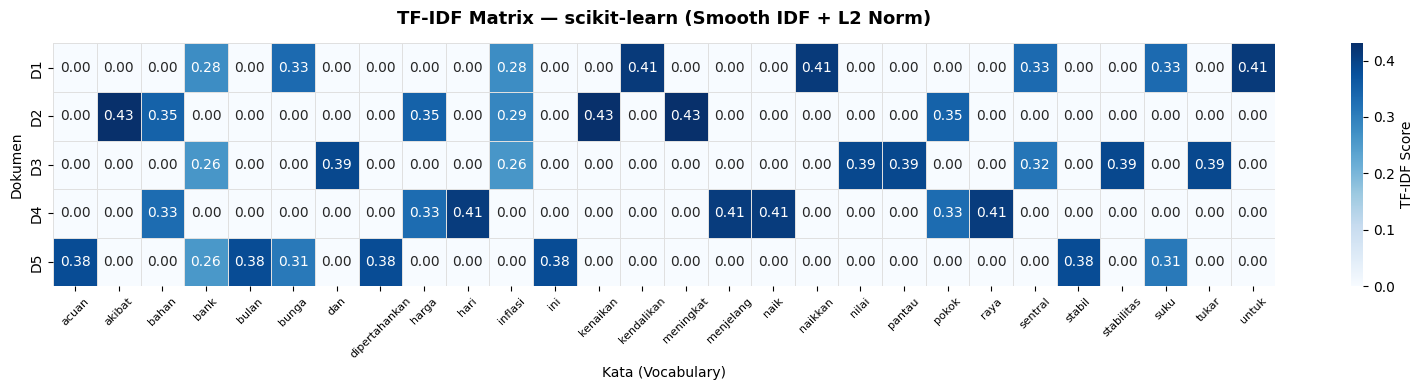

In [ ]:
# ── Visualisasi TF-IDF Heatmap ────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(16, 4))

sns.heatmap(
    tfidf_sklearn_df,
    annot=True, fmt='.2f',
    cmap='Blues',
    linewidths=0.5,
    linecolor='#e0e0e0',
    ax=ax,
    cbar_kws={'label': 'TF-IDF Score'}
)

ax.set_title('TF-IDF Matrix — scikit-learn (Smooth IDF + L2 Norm)',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Kata (Vocabulary)', fontsize=10)
ax.set_ylabel('Dokumen', fontsize=10)
ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.show()

---
# BAGIAN 3 — N-GRAM

## 3A. Demonstrasi Sliding Window (Manual)

In [ ]:
# ── Visualisasikan mekanisme sliding window N-gram ────────────────────────

def generate_ngrams(tokens, n):
    """
    Menghasilkan N-gram dari daftar token menggunakan sliding window.
    Window bergerak satu langkah ke kanan setiap iterasi (overlapping).
    """
    ngrams = []
    for i in range(len(tokens) - n + 1):
        gram = '_'.join(tokens[i : i + n])
        ngrams.append(gram)
    return ngrams


demo_sentence = "bank sentral naikkan suku bunga"
demo_tokens   = demo_sentence.split()

print(f"📝 Kalimat demo: \"{demo_sentence}\"")
print(f"   Tokens: {demo_tokens}")
print()

for n, label in [(1, 'Unigram'), (2, 'Bigram'), (3, 'Trigram')]:
    grams = generate_ngrams(demo_tokens, n)
    print(f"{'─'*55}")
    print(f"  {label} (n={n}) → {len(grams)} hasil")
    for idx, gram in enumerate(grams):
        start = idx
        end   = idx + n - 1
        window = demo_tokens[start:end+1]
        print(f"    [{start}:{end}] {window} → '{gram}'")

print()
print("💡 Window bergerak SATU LANGKAH ke kanan setiap kali → hasil overlapping.")
print("   'sentral' muncul di unigram 'sentral' DAN bigram 'bank_sentral' DAN 'sentral_naikkan'.")

📝 Kalimat demo: "bank sentral naikkan suku bunga"
   Tokens: ['bank', 'sentral', 'naikkan', 'suku', 'bunga']

───────────────────────────────────────────────────────
  Unigram (n=1) → 5 hasil
    [0:0] ['bank'] → 'bank'
    [1:1] ['sentral'] → 'sentral'
    [2:2] ['naikkan'] → 'naikkan'
    [3:3] ['suku'] → 'suku'
    [4:4] ['bunga'] → 'bunga'
───────────────────────────────────────────────────────
  Bigram (n=2) → 4 hasil
    [0:1] ['bank', 'sentral'] → 'bank_sentral'
    [1:2] ['sentral', 'naikkan'] → 'sentral_naikkan'
    [2:3] ['naikkan', 'suku'] → 'naikkan_suku'
    [3:4] ['suku', 'bunga'] → 'suku_bunga'
───────────────────────────────────────────────────────
  Trigram (n=3) → 3 hasil
    [0:2] ['bank', 'sentral', 'naikkan'] → 'bank_sentral_naikkan'
    [1:3] ['sentral', 'naikkan', 'suku'] → 'sentral_naikkan_suku'
    [2:4] ['naikkan', 'suku', 'bunga'] → 'naikkan_suku_bunga'

💡 Window bergerak SATU LANGKAH ke kanan setiap kali → hasil overlapping.
   'sentral' muncul di unigram 's

## 3B. N-Gram dengan scikit-learn

In [ ]:
# ── Unigram, Bigram, Trigram — masing-masing ─────────────────────────────

configs = [
    ("Unigram (1,1)",        (1, 1)),
    ("Bigram (2,2)",         (2, 2)),
    ("Trigram (3,3)",        (3, 3)),
    ("Uni+Bi+Tri (1,3)",     (1, 3)),  # kombinasi umum di praktik nyata
]

results = {}

for label, ngram_range in configs:
    vec = CountVectorizer(ngram_range=ngram_range)
    matrix = vec.fit_transform(corpus)
    vocab  = vec.get_feature_names_out()
    results[label] = {
        'vectorizer' : vec,
        'matrix'     : matrix,
        'vocab'      : vocab,
        'vocab_size' : len(vocab)
    }
    print(f"  {label:<25} → Vocabulary size: {len(vocab):>4} fitur")

print()
print("💡 Perhatikan lonjakan vocabulary size dari unigram ke n-gram yang lebih tinggi.")
print("   Di corpus nyata (jutaan dokumen), ini bisa mencapai ratusan juta fitur.")

  Unigram (1,1)             → Vocabulary size:   28 fitur
  Bigram (2,2)              → Vocabulary size:   29 fitur
  Trigram (3,3)             → Vocabulary size:   27 fitur
  Uni+Bi+Tri (1,3)          → Vocabulary size:   84 fitur

💡 Perhatikan lonjakan vocabulary size dari unigram ke n-gram yang lebih tinggi.
   Di corpus nyata (jutaan dokumen), ini bisa mencapai ratusan juta fitur.


In [ ]:
# ── Tampilkan vocabulary bigram ───────────────────────────────────────────

print("📋 Semua Bigram yang ditemukan di corpus:")
print("-" * 50)
bigram_vocab = results["Bigram (2,2)"]['vocab']
for i, gram in enumerate(bigram_vocab):
    print(f"  {i+1:>3}. {gram}")

print()
print("📋 Beberapa Trigram yang ditemukan:")
print("-" * 50)
trigram_vocab = results["Trigram (3,3)"]['vocab']
for i, gram in enumerate(trigram_vocab[:10]):  # tampilkan 10 pertama
    print(f"  {i+1:>3}. {gram}")
if len(trigram_vocab) > 10:
    print(f"  ... dan {len(trigram_vocab)-10} trigram lainnya")

📋 Semua Bigram yang ditemukan di corpus:
--------------------------------------------------
    1. acuan bank
    2. akibat kenaikan
    3. bahan pokok
    4. bank dipertahankan
    5. bank sentral
    6. bulan ini
    7. bunga acuan
    8. bunga untuk
    9. dan inflasi
   10. dipertahankan stabil
   11. harga bahan
   12. hari raya
   13. inflasi meningkat
   14. kenaikan harga
   15. kendalikan inflasi
   16. meningkat akibat
   17. menjelang hari
   18. naik menjelang
   19. naikkan suku
   20. nilai tukar
   21. pantau stabilitas
   22. pokok naik
   23. sentral naikkan
   24. sentral pantau
   25. stabil bulan
   26. stabilitas nilai
   27. suku bunga
   28. tukar dan
   29. untuk kendalikan

📋 Beberapa Trigram yang ditemukan:
--------------------------------------------------
    1. acuan bank dipertahankan
    2. akibat kenaikan harga
    3. bahan pokok naik
    4. bank dipertahankan stabil
    5. bank sentral naikkan
    6. bank sentral pantau
    7. bunga acuan bank
    8. bu

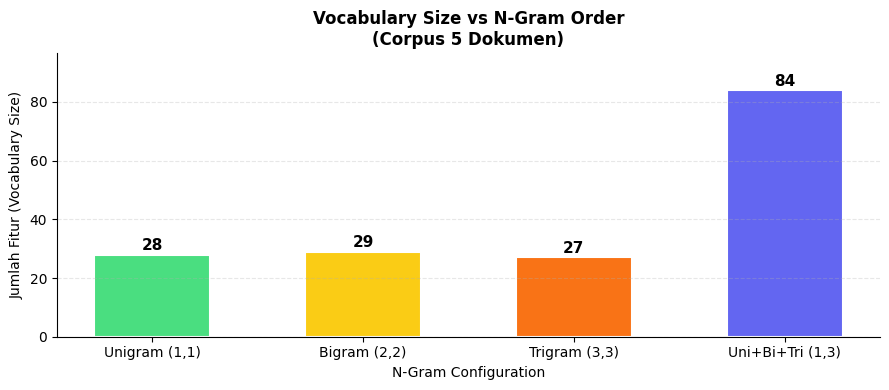

⚠️  Di corpus nyata, lonjakan ini jauh lebih dramatis.
    Ini alasan kenapa N-gram tinggi selalu dipasangkan dengan min_df filtering.


In [ ]:
# ── Visualisasi pertumbuhan vocabulary vs n-gram order ────────────────────

labels     = [r[0] for r in configs]
vocab_sizes = [r[1]['vocab_size'] for r in results.items()]

fig, ax = plt.subplots(figsize=(9, 4))

bar_colors = ['#4ade80', '#facc15', '#f97316', '#6366f1']
bars = ax.bar(labels, vocab_sizes, color=bar_colors, edgecolor='white',
              linewidth=1.5, width=0.55)

for bar, val in zip(bars, vocab_sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Vocabulary Size vs N-Gram Order\n(Corpus 5 Dokumen)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Jumlah Fitur (Vocabulary Size)', fontsize=10)
ax.set_xlabel('N-Gram Configuration', fontsize=10)
ax.set_ylim(0, max(vocab_sizes) * 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print("⚠️  Di corpus nyata, lonjakan ini jauh lebih dramatis.")
print("    Ini alasan kenapa N-gram tinggi selalu dipasangkan dengan min_df filtering.")

In [ ]:
# ── Strategi praktis: N-gram + TF-IDF + min_df filter ────────────────────
# Kombinasi ini paling umum dipakai di production

tfidf_ngram = TfidfVectorizer(
    ngram_range=(1, 2),  # unigram + bigram
    min_df=1,            # kata harus muncul di minimal 1 dokumen (di sini semua masuk)
    max_df=1.0,          # abaikan kata yang ada di > 100% dokumen
    max_features=30      # batasi ke 30 fitur teratas (berguna di corpus besar)
)

matrix_ngram_tfidf = tfidf_ngram.fit_transform(corpus)
vocab_ngram        = tfidf_ngram.get_feature_names_out()

df_ngram_tfidf = pd.DataFrame(
    matrix_ngram_tfidf.toarray(),
    columns=vocab_ngram,
    index=[f"D{i+1}" for i in range(len(corpus))]
)

print("📊 TF-IDF dengan N-gram (unigram + bigram), max_features=30:")
print(f"   Vocabulary size: {len(vocab_ngram)} fitur")
print()
print(df_ngram_tfidf.round(3).to_string())

📊 TF-IDF dengan N-gram (unigram + bigram), max_features=30:
   Vocabulary size: 30 fitur

    acuan bank  akibat  bahan  bahan pokok   bank  bank dipertahankan  bank sentral  bulan  bulan ini  bunga  bunga acuan  bunga untuk    dan  dan inflasi  dipertahankan  dipertahankan stabil  harga  harga bahan   hari  hari raya  inflasi  inflasi meningkat   ini  kenaikan  kenaikan harga  kendalikan  pokok  sentral   suku  suku bunga
D1        0.00    0.00  0.000        0.000  0.270                0.00         0.325   0.00       0.00  0.325         0.00        0.403  0.000        0.000           0.00                  0.00  0.000        0.000  0.000      0.000    0.270               0.00  0.00      0.00            0.00       0.403  0.000    0.325  0.325       0.325
D2        0.00    0.36  0.291        0.291  0.000                0.00         0.000   0.00       0.00  0.000         0.00        0.000  0.000        0.000           0.00                  0.00  0.291        0.291  0.000      0.000    0.2

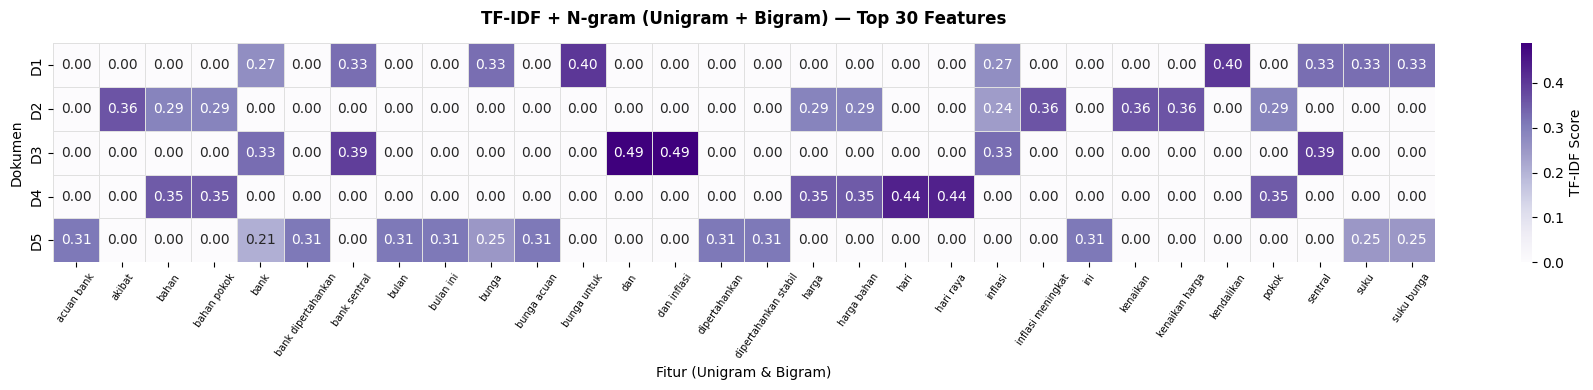

💡 Bigram seperti 'bank_sentral', 'suku_bunga', 'bahan_pokok' adalah fitur
   yang tidak bisa ditangkap BoW murni — konteksnya hilang.
   Dengan N-gram, frasa-frasa domain penting ini jadi fitur tersendiri.


In [ ]:
# ── Heatmap TF-IDF + N-gram ───────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(18, 4))

sns.heatmap(
    df_ngram_tfidf,
    annot=True, fmt='.2f',
    cmap='Purples',
    linewidths=0.5,
    linecolor='#e0e0e0',
    ax=ax,
    cbar_kws={'label': 'TF-IDF Score'}
)

ax.set_title('TF-IDF + N-gram (Unigram + Bigram) — Top 30 Features',
             fontsize=12, fontweight='bold', pad=14)
ax.set_xlabel('Fitur (Unigram & Bigram)', fontsize=10)
ax.set_ylabel('Dokumen', fontsize=10)
ax.tick_params(axis='x', rotation=55, labelsize=7)

plt.tight_layout()
plt.show()

print("💡 Bigram seperti 'bank_sentral', 'suku_bunga', 'bahan_pokok' adalah fitur")
print("   yang tidak bisa ditangkap BoW murni — konteksnya hilang.")
print("   Dengan N-gram, frasa-frasa domain penting ini jadi fitur tersendiri.")

---
# RANGKUMAN & PANDUAN PEMILIHAN TEKNIK

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════════════╗
║           PANDUAN PEMILIHAN FEATURE ENGINEERING                        ║
╠══════════════╦═════════════════════════════════╦════════════════════════╣
║ Teknik       ║ Gunakan Ketika                  ║ Hindari Ketika         ║
╠══════════════╬═════════════════════════════════╬════════════════════════╣
║ BoW          ║ Baseline cepat, dataset kecil,  ║ Butuh pemahaman makna  ║
║              ║ klasifikasi sederhana           ║ atau urutan kata       ║
╠══════════════╬═════════════════════════════════╬════════════════════════╣
║ TF-IDF       ║ Hampir semua task NLP klasik:   ║ Dataset sangat kecil   ║
║              ║ klasifikasi, clustering,        ║ (<50 dokumen), atau    ║
║              ║ information retrieval           ║ saat semantik penting  ║
╠══════════════╬═════════════════════════════════╬════════════════════════╣
║ N-gram       ║ Sentimen, deteksi frasa domain, ║ Corpus kecil + n besar ║
║ (1,2)/(1,3)  ║ jika negasi penting             ║ → vocabulary explosion ║
╠══════════════╬═════════════════════════════════╬════════════════════════╣
║ TF-IDF       ║ Production-grade NLP, dokumen   ║ Butuh semantik deep    ║
║ + N-gram     ║ panjang, domain-specific        ║ → pakai embeddings     ║
╠══════════════╬═════════════════════════════════╬════════════════════════╣
║ Word         ║ Similarity tasks, clustering    ║ Dataset sangat kecil   ║
║ Embeddings   ║ semantik, deep learning input   ║ tanpa pretrained model ║
╚══════════════╩═════════════════════════════════╩════════════════════════╝

REKOMENDASI ALUR EKSPERIMEN:
  1. Mulai dari TF-IDF (1,1) sebagai baseline
  2. Coba TF-IDF (1,2) — tambah bigram
  3. Bandingkan performa di validation set
  4. Jika masih kurang → pertimbangkan word embeddings
""")


╔══════════════════════════════════════════════════════════════════════════╗
║           PANDUAN PEMILIHAN FEATURE ENGINEERING                        ║
╠══════════════╦═════════════════════════════════╦════════════════════════╣
║ Teknik       ║ Gunakan Ketika                  ║ Hindari Ketika         ║
╠══════════════╬═════════════════════════════════╬════════════════════════╣
║ BoW          ║ Baseline cepat, dataset kecil,  ║ Butuh pemahaman makna  ║
║              ║ klasifikasi sederhana           ║ atau urutan kata       ║
╠══════════════╬═════════════════════════════════╬════════════════════════╣
║ TF-IDF       ║ Hampir semua task NLP klasik:   ║ Dataset sangat kecil   ║
║              ║ klasifikasi, clustering,        ║ (<50 dokumen), atau    ║
║              ║ information retrieval           ║ saat semantik penting  ║
╠══════════════╬═════════════════════════════════╬════════════════════════╣
║ N-gram       ║ Sentimen, deteksi frasa domain, ║ Corpus kecil + n besar ║
║ (1,2)/(1,